# Final Project: การวิเคราะห์ปัจจัยด้านวิถีชีวิตและสภาพร่างกายที่เกี่ยวข้องกับระดับน้ำหนักตัวและภาวะโรคอ้วน

> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2569

**สมาชิกในกลุ่ม:**

* สมาชิกที่ 1: นายเขษมศักดิ์ แก่นทน (68114540090)
* สมาชิกที่ 2: นายณัฐดนัย ทองสรรค์ (68114540184)

**Dataset:** Estimation of Obesity Levels Based On Eating Habits and Physical Condition

**แหล่งที่มาข้อมูล:**
https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

**Problem Statement:**
โครงงานนี้มีเป้าหมายเพื่อจำแนกระดับภาวะน้ำหนักตัวและโรคอ้วนออกเป็น **7 ระดับ** โดยอาศัยข้อมูลด้านพฤติกรรมการกิน การใช้ชีวิต สภาพร่างกาย และประวัติครอบครัว เพื่อศึกษาความสัมพันธ์ระหว่างตัวแปรต่าง ๆ กับระดับภาวะน้ำหนัก และประยุกต์ใช้แนวคิดทางคณิตศาสตร์สำหรับวิทยาการข้อมูลอย่างเป็นระบบ

---

|                  CLO                 | ส่วนที่ครอบคลุม                                                  | Status |
| :----------------------------------: | :--------------------------------------------------------------- | :----: |
| **CLO1 (Linear Algebra)**      | Part 2: Covariance Matrix, Eigendecomposition & PCA              |    ✅   |
| **CLO2 (Statistical Learning)**   | Part 3: Feature Distribution, Hypothesis Testing & Bias-Variance |    ✅   |
| **CLO3 (Regression/Classification)** | Part 4: Multi-class Logistic Regression & KNN Classifier         |    ✅   |
| **CLO4 (Model Selection)**      | Part 5: 5-Fold Stratified Cross-Validation & Model Selection     |    ✅   |


In [1]:
!pip install -q notebook numpy pandas scipy matplotlib seaborn scikit-learn statsmodels 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ─── Import libraries ──────────────────────────────────────────────
import os
import urllib.request
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
from scipy.stats import chi2_contingency, f_oneway

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

np.random.seed(42)

font_path = fm.findfont("TH Sarabun New", fallback_to_default=False)
print(font_path)

plt.rcParams["font.family"] = "TH Sarabun New"
sns.set_theme(
    style="whitegrid",
    rc={"font.family": "TH Sarabun New"}
)

warnings.filterwarnings('ignore')
%matplotlib inline

print("All libraries are ready.")

C:\Users\User\AppData\Local\Microsoft\Windows\Fonts\THSarabunNew.ttf
All libraries are ready.


In [18]:
# ค้นหา path ของไฟล์ตามสภาพแวดล้อมที่กำลังใช้งาน
if os.path.exists('/content'):
    file_path = '/content/obesity_lifestyle_health.csv'
    
elif os.path.exists('../data'):
    file_path = '../data/obesity_lifestyle_health.csv'
    
elif os.path.exists('data'):
    file_path = 'data/obesity_lifestyle_health.csv'
    
else:
    file_path = 'obesity_lifestyle_health.csv'


# URL สำหรับดาวน์โหลด Dataset อัตโนมัติ
url = 'https://raw.githubusercontent.com/kasemsakKK06/math-ds-obesity-project/main/data/obesity_lifestyle_health.csv'


# ถ้าไม่พบไฟล์ในเครื่อง ให้ดาวน์โหลดจาก GitHub
if not os.path.exists(file_path):
    print(f"กำลังดาวน์โหลดไฟล์ไปยัง: {file_path} ...")
    
    os.makedirs(
        os.path.dirname(file_path) if os.path.dirname(file_path) else '.',
        exist_ok=True
    )
    
    urllib.request.urlretrieve(url, file_path)
    print(f"ดาวน์โหลดและบันทึกไฟล์ไปที่ '{file_path}' เรียบร้อย!")

# ถ้ามีไฟล์อยู่แล้ว ให้ใช้งานไฟล์เดิม
else:
    print(f"พบไฟล์ที่: {file_path}")
    print(f"ใช้งานไฟล์ที่: {file_path}")

พบไฟล์ที่: ../data/obesity_lifestyle_health.csv
ใช้งานไฟล์ที่: ../data/obesity_lifestyle_health.csv


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

### 1.1 Data Understanding & Cleaning
ขั้นตอนแรกคือการนำเข้าชุดข้อมูลเพื่อตรวจสอบมิติ (Shape), ประเภทตัวแปร (Data Types), และหาความผิดปกติเบื้องต้น เช่น ค่าที่ขาดหายไป (Missing Values) หรือข้อมูลที่บันทึกซ้ำซ้อน (Duplicates)

In [4]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลก่อนวิเคราะห์

# โหลด Dataset จาก path ที่กำหนดไว้
df = pd.read_csv(file_path)

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')

display(df.head())

# ─── ตรวจสอบและจัดการแถวข้อมูลซ้ำ (Duplicates) ─────────────────────
n_dup = df.duplicated().sum()
print(f"พบแถวข้อมูลซ้ำทั้งหมด: {n_dup} แถว")

if n_dup > 0:
    df_clean = df.drop_duplicates().reset_index(drop=True)
    print(f"ขนาดข้อมูลหลัง Clean: {df_clean.shape[0]} แถว, {df_clean.shape[1]} คอลัมน์")
else:
    df_clean = df.copy()
    print("โครงสร้างข้อมูลสะอาด ไม่พบแถวซ้ำ")

Shape: (2111, 17)
Columns: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']
Missing values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


พบแถวข้อมูลซ้ำทั้งหมด: 24 แถว
ขนาดข้อมูลหลัง Clean: 2087 แถว, 17 คอลัมน์


### 1.2 สถิติเชิงพรรณนา (Descriptive Statistics)
ตรวจสอบค่าสถิติพื้นฐานของข้อมูล เช่น ค่าเฉลี่ย (Mean), ส่วนเบี่ยงเบนมาตรฐาน (Std), และค่าต่ำสุด-สูงสุด (Min-Max) เพื่อดูการกระจายตัวและช่วงของข้อมูลแต่ละตัวแปร

In [5]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูลเชิงตัวเลขและเชิงกลุ่ม

print("=== สถิติเชิงพรรณนาของตัวแปรเชิงตัวเลข (Numerical) ===")
display(df_clean.describe().T)

print("\n=== สถิติเชิงพรรณนาของตัวแปรเชิงกลุ่ม (Categorical) ===")
display(df_clean.describe(include=['object']).T)

=== สถิติเชิงพรรณนาของตัวแปรเชิงตัวเลข (Numerical) ===


,count,mean,std,min,25%,50%,75%,max
Age,2087.0,24.353090,6.368801,14.00,19.915937,22.847618,26.000000,61.00
Height,2087.0,1.702674,0.093186,1.45,1.630178,1.701584,1.769491,1.98
Weight,2087.0,86.858730,26.190847,39.00,66.000000,83.101100,108.015907,173.00
FCVC,2087.0,2.421466,0.534737,1.00,2.000000,2.396265,3.000000,3.00
NCP,2087.0,2.701179,0.764614,1.00,2.697467,3.000000,3.000000,4.00
CH2O,2087.0,2.004749,0.608284,1.00,1.590922,2.000000,2.466193,3.00
FAF,2087.0,1.012812,0.853475,0.00,0.124505,1.000000,1.678102,3.00
TUE,2087.0,0.663035,0.608153,0.00,0.000000,0.630866,1.000000,2.00



=== สถิติเชิงพรรณนาของตัวแปรเชิงกลุ่ม (Categorical) ===


,count,unique,top,freq
Gender,2087,2,Male,1052
family_history_with_overweight,2087,2,yes,1722
FAVC,2087,2,yes,1844
CAEC,2087,4,Sometimes,1761
SMOKE,2087,2,no,2043
SCC,2087,2,no,1991
CALC,2087,4,Sometimes,1380
MTRANS,2087,5,Public_Transportation,1558
NObeyesdad,2087,7,Obesity_Type_I,351


### 1.3 การกระจายตัวของ Target Variable (NObeyesdad)
ตรวจสอบความสมดุลของคลาสเป้าหมาย (Class Balance) เพื่อดูว่ามีกลุ่มระดับความอ้วนใดที่มีจำนวนข้อมูลน้อยหรือมากผิดปกติหรือไม่ ซึ่งจะมีผลต่อการเลือกใช้ Metric วัดผลประเมินโมเดลในภายหลัง

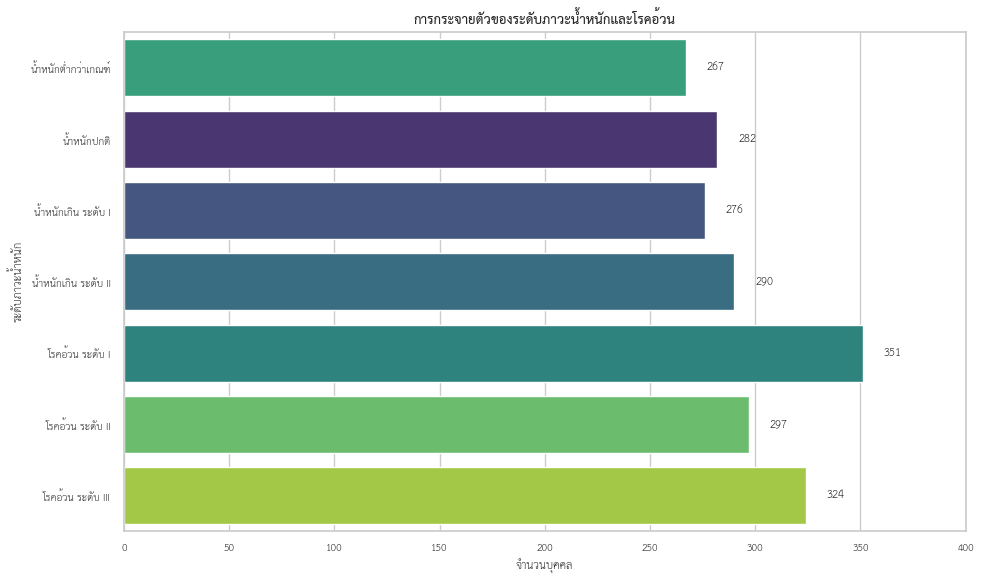

In [6]:
# ─── 1.3 การกระจายตัวของ Target Variable ─────────────────────────────
# วัตถุประสงค์: ตรวจสอบจำนวนข้อมูลในแต่ละระดับของ Target Variable

target_order = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

# กำหนดชื่อระดับภาวะน้ำหนักเป็นภาษาไทยสำหรับการแสดงผล
target_labels = {
    'Insufficient_Weight': 'น้ำหนักต่ำกว่าเกณฑ์',
    'Normal_Weight': 'น้ำหนักปกติ',
    'Overweight_Level_I': 'น้ำหนักเกิน ระดับ I',
    'Overweight_Level_II': 'น้ำหนักเกิน ระดับ II',
    'Obesity_Type_I': 'โรคอ้วน ระดับ I',
    'Obesity_Type_II': 'โรคอ้วน ระดับ II',
    'Obesity_Type_III': 'โรคอ้วน ระดับ III'
}

thai_order = [target_labels[x] for x in target_order]

plt.figure(figsize=(10, 6))

# สร้างกราฟแสดงจำนวนข้อมูลในแต่ละระดับ
ax = sns.countplot(
    y=df_clean['NObeyesdad'].map(target_labels),
    order=thai_order,
    palette='viridis',
    hue=df_clean['NObeyesdad'].map(target_labels),
    legend=False
)

# แสดงจำนวนข้อมูลที่ปลายแท่งกราฟ
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_width())}',
        (p.get_width() + 10, p.get_y() + p.get_height() / 2),
        va='center'
    )

plt.title('การกระจายตัวของระดับภาวะน้ำหนักและโรคอ้วน', fontsize=14, fontweight='bold')
plt.xlabel('จำนวนบุคคล')
plt.ylabel('ระดับภาวะน้ำหนัก')
plt.xlim(0, 400)

plt.tight_layout()
plt.show()

### 1.4 Correlation Heatmap
วิเคราะห์ความสัมพันธ์เชิงเส้น (Linear Correlation) ระหว่างตัวแปรเชิงตัวเลขทั้งหมด เพื่อประเมินว่ามีตัวแปรคู่ใดที่มีความสัมพันธ์กันสูงมากจนอาจก่อให้เกิดปัญหา Multicollinearity หรือไม่

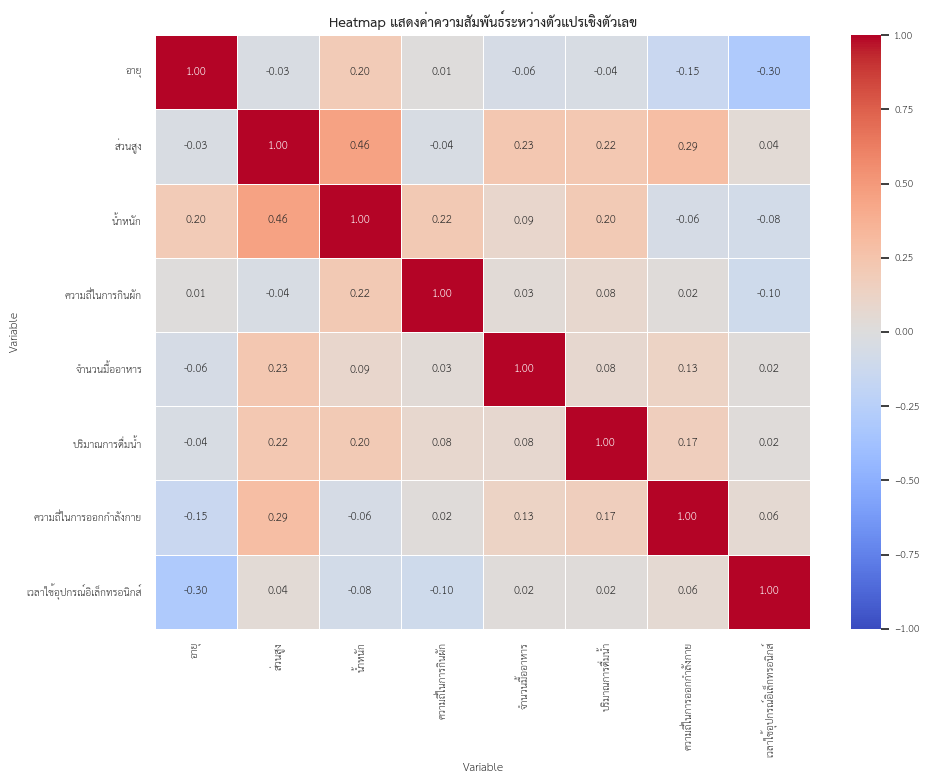

In [7]:
# ─── Heatmap ค่าความสัมพันธ์ระหว่างตัวแปรทั้งหมด ──────────────────────────────────────
# วัตถุประสงค์: ตรวจสอบความสัมพันธ์ระหว่างตัวแปรเชิงตัวเลข

plt.figure(figsize=(10, 8))

# เลือกเฉพาะตัวแปรที่เป็นข้อมูลเชิงตัวเลข
numeric_cols = df_clean.select_dtypes(
    include=['float64', 'int64']
).columns

corr_matrix = df_clean[numeric_cols].corr()

# เปลี่ยนชื่อตัวแปรเป็นภาษาไทยเพื่อใช้แสดงผล
column_labels = {
    'Age': 'อายุ',
    'Height': 'ส่วนสูง',
    'Weight': 'น้ำหนัก',
    'FCVC': 'ความถี่ในการกินผัก',
    'NCP': 'จำนวนมื้ออาหาร',
    'CH2O': 'ปริมาณการดื่มน้ำ',
    'FAF': 'ความถี่ในการออกกำลังกาย',
    'TUE': 'เวลาใช้อุปกรณ์อิเล็กทรอนิกส์'
}

corr_matrix_thai = corr_matrix.rename(
    index=column_labels, columns=column_labels
)

# แสดงค่าความสัมพันธ์ในรูปแบบ Heatmap
sns.heatmap(
    corr_matrix_thai,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Heatmap แสดงค่าความสัมพันธ์ระหว่างตัวแปรเชิงตัวเลข', fontsize=14, fontweight='bold')
plt.xlabel('Variable')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

### 1.5 Boxplot Analysis (Numerical vs Target)
ใช้ Boxplot เพื่อเปรียบเทียบการกระจายตัวของอายุ (Age) และน้ำหนัก (Weight) ในแต่ละระดับความอ้วน ซึ่งจะช่วยให้เห็นค่ากลาง การกระจายตัว และตรวจจับจุดข้อมูลที่ผิดปกติ (Outliers) ก่อนนำไปสรุปผล

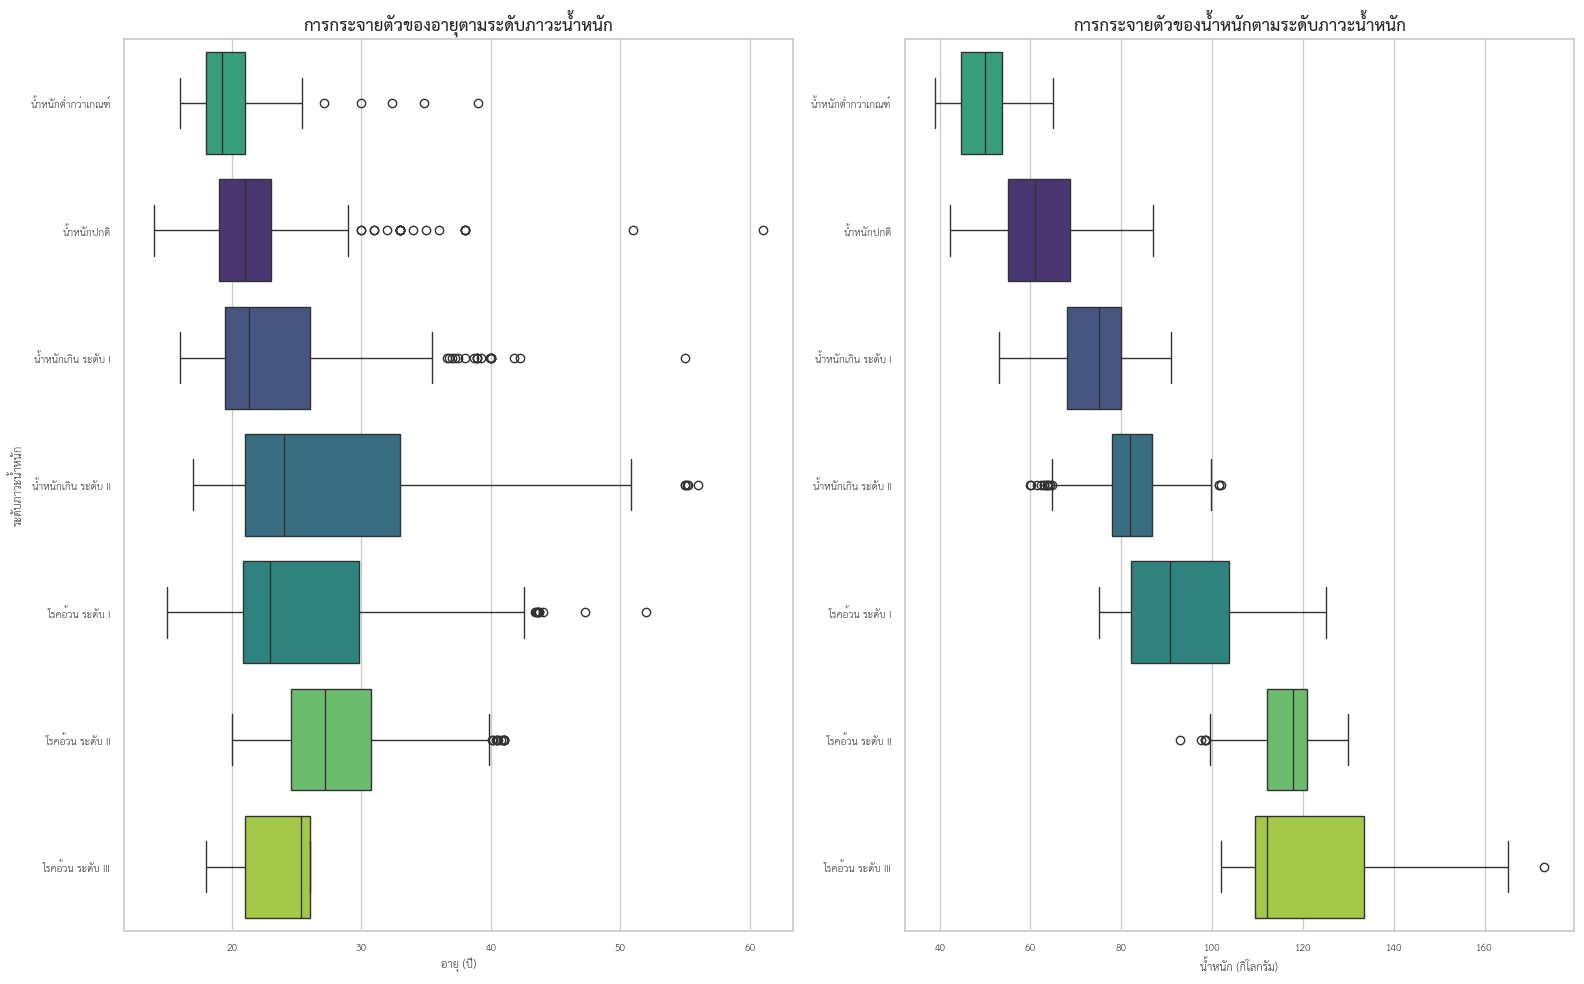

In [8]:
# ─── 1.5 Boxplot: เปรียบเทียบตัวแปรเชิงตัวเลขตามระดับภาวะน้ำหนัก ─────────
# วัตถุประสงค์: เปรียบเทียบการกระจายตัวของอายุและน้ำหนักในแต่ละระดับภาวะน้ำหนัก

target_labels = {
    'Insufficient_Weight': 'น้ำหนักต่ำกว่าเกณฑ์',
    'Normal_Weight': 'น้ำหนักปกติ',
    'Overweight_Level_I': 'น้ำหนักเกิน ระดับ I',
    'Overweight_Level_II': 'น้ำหนักเกิน ระดับ II',
    'Obesity_Type_I': 'โรคอ้วน ระดับ I',
    'Obesity_Type_II': 'โรคอ้วน ระดับ II',
    'Obesity_Type_III': 'โรคอ้วน ระดับ III'
}

thai_order = [target_labels[x] for x in target_order]

y_thai = df_clean['NObeyesdad'].map(target_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# ─── กราฟที่ 1: อายุ ─────────────────────────────────────────────
# แสดงการกระจายตัวของอายุในแต่ละระดับภาวะน้ำหนัก
sns.boxplot(
    data=df_clean, x='Age', y=y_thai,
    order=thai_order, hue=y_thai, palette='viridis', legend=False, ax=axes[0]
)
axes[0].set_title('การกระจายตัวของอายุตามระดับภาวะน้ำหนัก', fontsize=18, fontweight='bold')
axes[0].set_xlabel('อายุ (ปี)')
axes[0].set_ylabel('ระดับภาวะน้ำหนัก')

# ─── กราฟที่ 2: น้ำหนัก ──────────────────────────────────────────
# แสดงการกระจายตัวของน้ำหนักในแต่ละระดับภาวะน้ำหนัก
sns.boxplot(
    data=df_clean, x='Weight', y=y_thai,
    order=thai_order, hue=y_thai, palette='viridis', legend=False, ax=axes[1]
)
axes[1].set_title('การกระจายตัวของน้ำหนักตามระดับภาวะน้ำหนัก', fontsize=18, fontweight='bold')
axes[1].set_xlabel('น้ำหนัก (กิโลกรัม)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 1.6 การทดสอบสมมติฐานทางสถิติ (Hypothesis Testing)
เพื่อยืนยันว่าสิ่งที่เราสังเกตเห็นจากกราฟมีนัยสำคัญทางสถิติหรือไม่ เราจะทำการทดสอบ 2 ส่วน:
1. **ANOVA Test:** ทดสอบว่า "ค่าเฉลี่ยอายุ (Age) ของคนทั้ง 7 กลุ่มระดับความอ้วน แตกต่างกันหรือไม่"
2. **Chi-Square Test:** ทดสอบว่า "ประวัติความอ้วนของครอบครัว (family_history) มีความสัมพันธ์กับระดับความอ้วน (NObeyesdad) หรือไม่"
*(เกณฑ์การตัดสินใจ: หาก p-value < 0.05 จะปฏิเสธสมมติฐานหลัก $H_0$)*

In [9]:
# ─── 1.6 การทดสอบสมมติฐานทางสถิติ (ANOVA & Chi-Square) ───────────────────
# วัตถุประสงค์: ทดสอบความแตกต่างและความสัมพันธ์ของตัวแปรกับระดับภาวะน้ำหนัก

# --- 1. ANOVA Test ---
print("=== 1. ANOVA: ทดสอบความแตกต่างของอายุ (Age) ระหว่างกลุ่มความอ้วน ===")

# แบ่งข้อมูลอายุออกตามระดับภาวะน้ำหนักทั้ง 7 กลุ่ม
age_groups = [df_clean[df_clean['NObeyesdad'] == level]['Age'] for level in target_order]
f_stat, p_value_anova = f_oneway(*age_groups)

print(f"F-Statistic: {f_stat:.4f} | p-value: {p_value_anova:.4e}")
if p_value_anova < 0.05:
    print("สรุป: ปฏิเสธ H0 -> ค่าเฉลี่ยอายุของแต่ละระดับความอ้วน แตกต่างกันอย่างมีนัยสำคัญ")
else:
    print("สรุป: ยอมรับ H0 -> ค่าเฉลี่ยอายุไม่แตกต่างกัน")

print("\n" + "="*70 + "\n")

# --- 2. Chi-Square Test ---
print("=== 2. Chi-Square: ประวัติครอบครัวที่มีภาวะน้ำหนักเกิน vs ระดับภาวะน้ำหนัก ===")

# สร้างตารางความถี่ระหว่างประวัติครอบครัวกับระดับภาวะน้ำหนัก
contingency_table = pd.crosstab(df_clean['family_history_with_overweight'], df_clean['NObeyesdad'])
display(contingency_table)

chi2_stat, p_val_chi, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2-Statistic: {chi2_stat:.4f} | p-value: {p_val_chi:.4e}")
if p_val_chi < 0.05:
    print("สรุป: ปฏิเสธ H0 -> ประวัติครอบครัวมีความสัมพันธ์กับระดับความอ้วนอย่างมีนัยสำคัญ")
else:
    print("สรุป: ยอมรับ H0 -> ประวัติครอบครัวไม่มีความสัมพันธ์กับระดับความอ้วน")

=== 1. ANOVA: ทดสอบความแตกต่างของอายุ (Age) ระหว่างกลุ่มความอ้วน ===
F-Statistic: 76.1954 | p-value: 3.2469e-86
สรุป: ปฏิเสธ H0 -> ค่าเฉลี่ยอายุของแต่ละระดับความอ้วน แตกต่างกันอย่างมีนัยสำคัญ


=== 2. Chi-Square: ประวัติครอบครัวที่มีภาวะน้ำหนักเกิน vs ระดับภาวะน้ำหนัก ===


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
family_history_with_overweight,,,,,,,
no,142,130,7,1,0,67,18
yes,125,152,344,296,324,209,272


Chi2-Statistic: 617.7110 | p-value: 3.5242e-130
สรุป: ปฏิเสธ H0 -> ประวัติครอบครัวมีความสัมพันธ์กับระดับความอ้วนอย่างมีนัยสำคัญ


### 💡 สรุป Insight จากการสำรวจข้อมูลเบื้องต้น (EDA & สถิติ)

1. **คุณภาพ & ความสมดุล:** ข้อมูลสะอาด (2,087 แถว) ไม่มี Missing Values และคลาสเป้าหมายสมดุลกันพร้อมนำไปสร้างโมเดล
2. **ความสัมพันธ์เชิงเส้น:** ตัวแปรเชิงตัวเลขไม่มีปัญหา Multicollinearity (สัมพันธ์กันเองต่ำ) 
3. **ความแตกต่างและปัจจัยที่ส่งผล:** 
   - **อายุ (Age):** กระจุกตัวแตกต่างกันในแต่ละระดับความอ้วน (ยืนยันด้วย ANOVA p-value < 0.05)
   - **น้ำหนัก (Weight):** สามารถแยกกลุ่มระดับความอ้วนได้อย่างชัดเจนที่สุด
   - **พันธุกรรม (Family History):** มีความสัมพันธ์กับระดับความอ้วนอย่างมีนัยสำคัญ (ยืนยันด้วย Chi-Square p-value < 0.05)

จากการสำรวจข้อมูลและทดสอบสมมติฐานทางสถิติ ทำให้เราเห็นภาพรวมว่าชุดข้อมูลมีความพร้อมสูงมากสำหรับการวิเคราะห์ขั้นสูง ข้อมูลทั้ง 2,087 แถวมีความสมบูรณ์ คลาสเป้าหมายกระจายตัวอย่างสมดุล และตัวแปรเชิงตัวเลขไม่มีปัญหา Multicollinearity ที่จะรบกวนการเรียนรู้ของโมเดล

นอกจากนี้ ผลทดสอบสถิติยังช่วยยืนยันข้อสังเกตจากกราฟว่าปัจจัยส่วนบุคคล ทั้งช่วงอายุ (Age) และประวัติครอบครัว (Family History) มีผลต่อระดับความอ้วนอย่างมีนัยสำคัญ ข้อมูลเชิงลึกทั้งหมดนี้เป็นฐานรากที่แข็งแกร่งสำหรับการนำไปทำ Data Preprocessing (Encoding & Scaling) และการใช้คณิตศาสตร์เชิงเส้น (PCA) เพื่อสกัดคุณลักษณะที่สำคัญในขั้นตอนต่อไป

---
#### **การเตรียมข้อมูล (Data Preprocessing)**
ก่อนเข้าสู่การคำนวณด้วย Linear Algebra (PCA) และ Machine Learning เราต้องเตรียมข้อมูลให้พร้อมในรูปแบบตัวเลขและสเกลเดียวกัน:
1. **Encoding:** แปลงข้อมูลเชิงกลุ่ม (Categorical) ให้เป็นตัวเลขด้วย One-Hot Encoding
2. **Scaling:** ปรับสเกลข้อมูลให้อยู่ในมาตรฐานเดียวกัน (Standardization) เพื่อไม่ให้ตัวแปรที่มีค่าสูงมีอิทธิพลต่อโมเดลมากเกินไป

In [10]:
# ─── Data Preprocessing (Encoding & Scaling) ───────────────────────────
# วัตถุประสงค์: เตรียมข้อมูลให้อยู่ในรูปแบบที่เหมาะสมสำหรับการวิเคราะห์และทำ PCA

df_processed = df_clean.copy()

# 1. แยก Features (X) และ Target (y)
X = df_processed.drop(columns=['NObeyesdad'])
y = df_processed['NObeyesdad']

# 2. One-Hot Encoding (แปลงข้อความเป็น 0, 1)
# แปลงตัวแปรประเภทข้อความให้อยู่ในรูปแบบตัวเลข
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"จำนวน Features ก่อน Encode: {X.shape[1]} คอลัมน์")
print(f"จำนวน Features หลัง Encode: {X_encoded.shape[1]} คอลัมน์\n")

# 3. Standardization (ปรับสเกลข้อมูลให้ Mean=0, Std=1)
# ปรับสเกลตัวแปรให้อยู่บนมาตรฐานเดียวกันก่อนทำ PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("=== ตัวอย่างข้อมูลหลังผ่าน StandardScaler (พร้อมเข้าสู่ PCA) ===")
display(X_scaled_df.head())

จำนวน Features ก่อน Encode: 16 คอลัมน์
จำนวน Features หลัง Encode: 23 คอลัมน์

=== ตัวอย่างข้อมูลหลังผ่าน StandardScaler (พร้อมเข้าสู่ PCA) ===


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,-0.526613,-0.887408,-0.872985,-0.788364,0.390906,-0.007810,-1.186977,0.554211,-1.008179,0.460394,...,-0.134346,-0.146755,-0.219584,-0.186293,-1.397108,1.510446,-0.058012,-0.072792,0.582699,-0.164520
1,-0.526613,-1.960788,-1.178508,1.082164,0.390906,1.636552,2.328908,-1.090505,-1.008179,0.460394,...,-0.134346,6.814090,4.554073,-0.186293,0.715765,-0.662056,-0.058012,-0.072792,0.582699,-0.164520
2,-0.212507,1.044677,-0.376509,-0.788364,0.390906,-0.007810,1.156947,0.554211,0.991887,0.460394,...,-0.134346,-0.146755,-0.219584,5.367894,-1.397108,-0.662056,-0.058012,-0.072792,0.582699,-0.164520
3,0.415705,1.044677,0.005395,1.082164,0.390906,-0.007810,1.156947,-1.090505,0.991887,-2.172052,...,-0.134346,-0.146755,-0.219584,5.367894,-1.397108,-0.662056,-0.058012,-0.072792,-1.716153,6.078277
4,-0.369560,0.830001,0.112328,-0.788364,-2.225418,-0.007810,-1.186977,-1.090505,0.991887,-2.172052,...,-0.134346,-0.146755,-0.219584,-0.186293,0.715765,-0.662056,-0.058012,-0.072792,0.582699,-0.164520


---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ให้ใช้ Linear Algebra เพื่อ analyze dataset

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**เลือกทำ: Task A  — PCA: ลด dimension ของ features + Scree Plot + 2D visualization**

**คำอธิบาย:** เลือกใช้เทคนิค PCA เนื่องจากชุดข้อมูลของเรามีตัวแปรอิสระ (Features) หลังทำ Encoding มากถึง 23 ตัวแปร ซึ่งเป็น Data ที่มีมิติสูง (High-dimensionality) ทำให้ไม่สามารถมองเห็นความสัมพันธ์ในภาพรวมได้ การทำ PCA จะใช้หลักการทางคณิตศาสตร์ (Eigendecomposition ของ Covariance Matrix) เพื่อสกัดและถูกใช้เพื่อลดมิติและวิเคราะห์โครงสร้างของข้อมูล โดยใช้ PC1 และ PC2 สำหรับการแสดงผลแบบ 2 มิติ (2D Visualization) ที่อธิบายความแปรปรวน (Variance) ได้มากที่สุด Insight ที่คาดว่าจะได้รับคือการสร้าง 2D Visualization เพื่อดูว่าผู้ที่มีระดับความอ้วนต่างกัน จะมีการเกาะกลุ่ม (Cluster) หรือแบ่งแยกออกจากกันอย่างชัดเจนในแกนพื้นที่ใหม่ (New Feature Space) หรือไม่

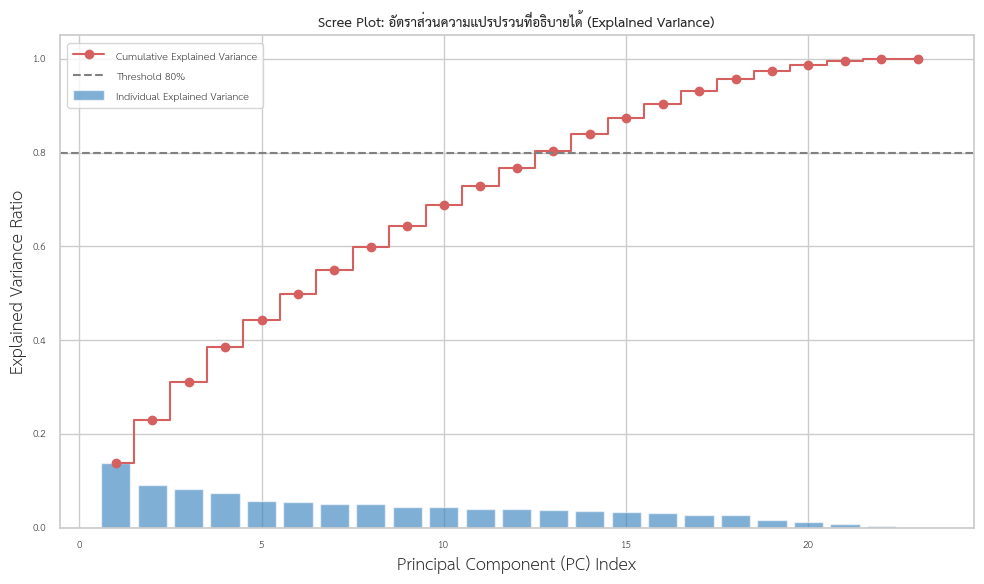

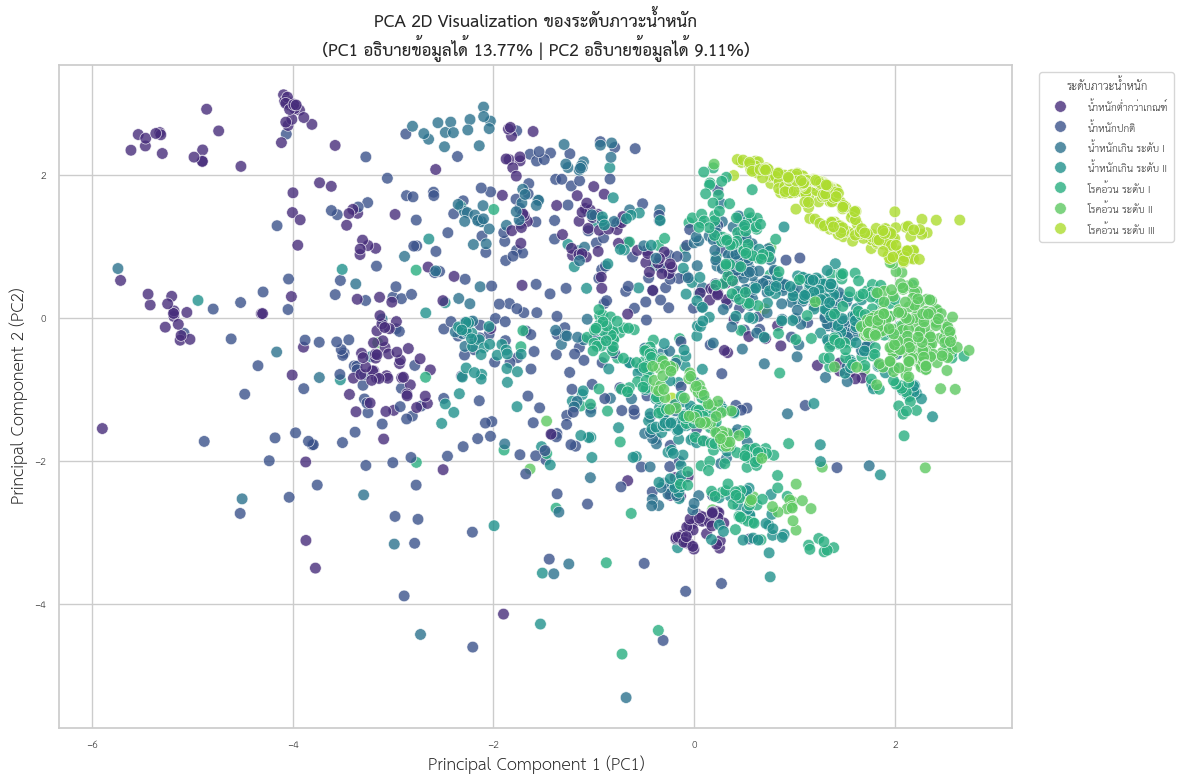

In [11]:
# ─── CLO1: Linear Algebra Analysis ──────────────────────────────
# วัตถุประสงค์: วิเคราะห์โครงสร้างของข้อมูลด้วย PCA และ Explained Variance

# ─── Task A.1: PCA & Scree Plot ──────────────────────────────────────────
# คำนวณ Principal Components และสัดส่วนความแปรปรวนที่แต่ละองค์ประกอบอธิบายได้
pca = PCA()
X_pca = pca.fit_transform(X_scaled_df)

exp_var_ratio = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var_ratio)

# แสดง Scree Plot และ Cumulative Explained Variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.6, align='center',
        label='Individual Explained Variance', color='#2b7bba')
plt.step(range(1, len(cum_exp_var) + 1), cum_exp_var, where='mid',
        label='Cumulative Explained Variance', color='#d65f5f', marker='o')

plt.title('Scree Plot: อัตราส่วนความแปรปรวนที่อธิบายได้ (Explained Variance)', fontsize=14, fontweight='bold')
plt.ylabel('Explained Variance Ratio', fontsize=18)
plt.xlabel('Principal Component (PC) Index', fontsize=18)
plt.axhline(y=0.80, color='gray', linestyle='--', label='Threshold 80%')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# ─── Task A.2: 2D Visualization (PC1 vs PC2) ─────────────────────────────
# เลือก PC1 และ PC2 สำหรับแสดงข้อมูลในรูปแบบ 2 มิติ
pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])

plt.figure(figsize=(12, 8))

# แสดงการกระจายของข้อมูลแต่ละระดับภาวะน้ำหนักบนแกน PC1 และ PC2
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2',
    hue=df_processed['NObeyesdad'].map(target_labels).values,
    hue_order=thai_order,
    palette='viridis',
    alpha=0.8, s=70, edgecolor='white', linewidth=0.5
)

plt.title(f'PCA 2D Visualization ของระดับภาวะน้ำหนัก\n(PC1 อธิบายข้อมูลได้ {exp_var_ratio[0]*100:.2f}% | PC2 อธิบายข้อมูลได้ {exp_var_ratio[1]*100:.2f}%)',
    fontsize=18, fontweight='bold'
)
plt.xlabel(f'Principal Component 1 (PC1)', fontsize=18)
plt.ylabel(f'Principal Component 2 (PC2)', fontsize=18)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='ระดับภาวะน้ำหนัก')
plt.tight_layout()
plt.show()

**Insight จาก CLO1 Analysis:**

>1. **การลดมิติข้อมูล (Dimensionality Reduction):** จากตัวแปรทั้งหมด 23 คอลัมน์ (หลังทำ Encoding) พบว่า Principal Component แกนแรกๆ สามารถอธิบายความแปรปรวน (Variance) ของข้อมูลได้ค่อนข้างดี โดยหากต้องการรักษาข้อมูลให้ได้ถึงเกณฑ์ 80% จะต้องใช้ประมาณ 13-14 Components
>
>2. **การแยกแยะกลุ่ม (Class Separability):** แม้จะหยิบมาแสดงผลเพียง 2 มิติแรก (PC1 และ PC2 ซึ่งอธิบายข้อมูลรวมกันได้ประมาณ 22.8%) แต่ 2D Visualization แสดงให้เห็นทิศทางการเกาะกลุ่มกันอย่างชัดเจน โดยเฉพาะกลุ่ม "น้ำหนักต่ำกว่าเกณฑ์/น้ำหนักปกติ" ที่แยกตัวออกจากกลุ่ม "โรคอ้วนระดับ II และ III" บนแกน PC1 ได้อย่างเป็นระเบียบ 
>
>3. **ข้อสรุปก่อนทำโมเดล:** การที่สมการ Linear Algebra สามารถดึงความแตกต่างของระดับความอ้วนออกมาจัดเรียงบนแกนพื้นที่ใหม่ได้อย่างชัดเจน เป็นสัญญาณที่ยอดเยี่ยมว่าข้อมูลชุดนี้มี Patterns ที่แข็งแกร่ง และ Machine Learning Model จะสามารถเรียนรู้เพื่อแยกประเภทคลาสเหล่านี้ได้อย่างแม่นยำแน่นอน

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

**ตอบ:** ชุดข้อมูลนี้เหมาะกับ **Classification (การจำแนกประเภท)** ครับ เนื่องจากตัวแปรเป้าหมาย (Target Variable) ของเราคือ `NObeyesdad` (ระดับความอ้วน) ซึ่งเป็นข้อมูลแบบกลุ่ม (Categorical Data) ที่จัดแบ่งเป็น 7 คลาสอย่างชัดเจน ไม่ใช่ค่าตัวเลขต่อเนื่อง (Continuous Variable) อย่างเช่น ราคาบ้าน หรือ อุณหภูมิ ดังนั้นเป้าหมายของ Statistical Learning ในโจทย์นี้คือการหารอยต่อ (Decision Boundary) เพื่อแยกคนแต่ละกลุ่มออกจากกันครับ

### 3.1 การกระจายตัวของข้อมูล (Distribution of Important Features)
เพื่อทำความเข้าใจคุณสมบัติทางสถิติเบื้องต้น (Statistical Properties) เราจะใช้ Histogram ควบคู่กับเส้น KDE (Kernel Density Estimate) สำรวจการกระจายตัวของตัวแปรเชิงตัวเลขที่สำคัญ ได้แก่ อายุ (Age), น้ำหนัก (Weight) และส่วนสูง (Height) เพื่อสังเกตว่าข้อมูลมีการกระจายตัวแบบปกติ (Normal Distribution) หรือมีความเบ้ (Skewness) มากน้อยเพียงใด

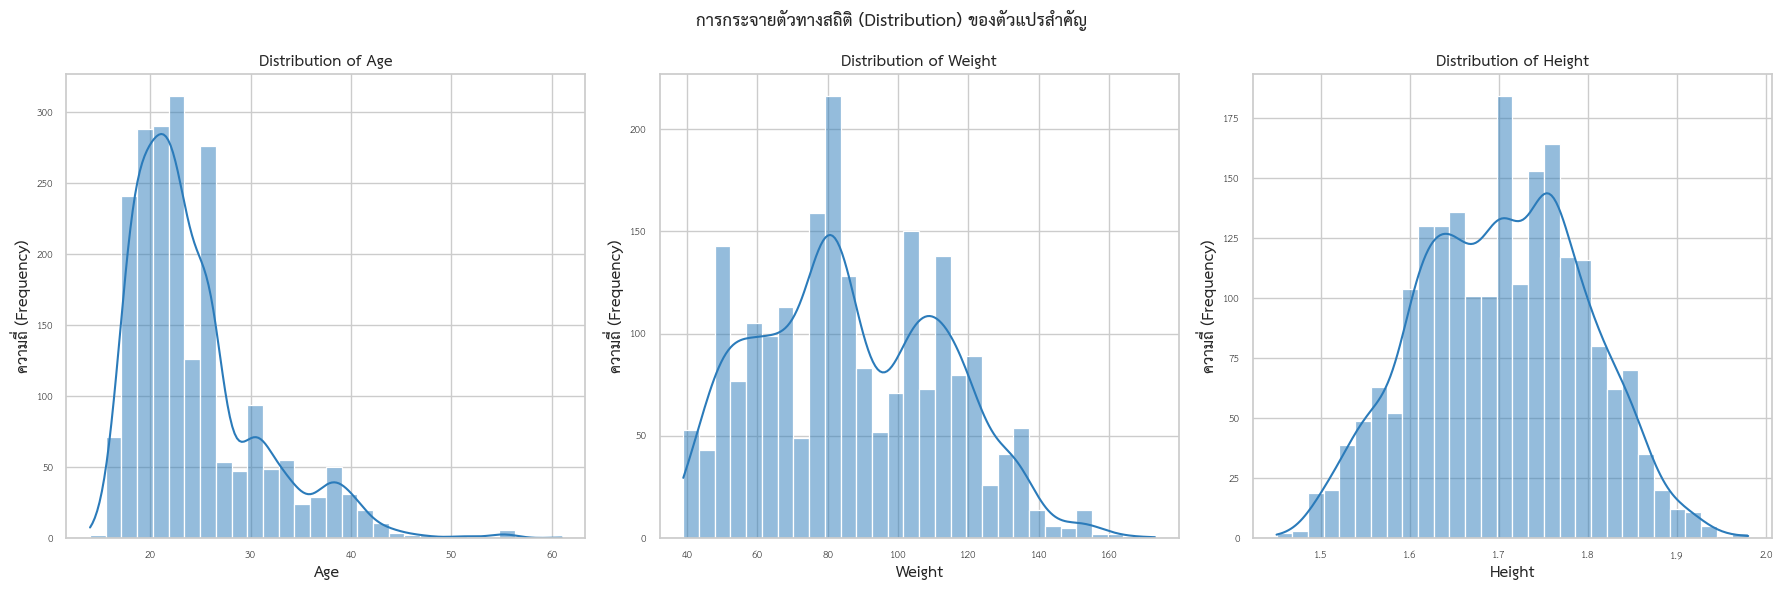

In [12]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────
# วัตถุประสงค์: วิเคราะห์การกระจายตัวทางสถิติของตัวแปรสำคัญใน Dataset

# ─── 3.1 แสดง Distribution ของ Features สำคัญทางสถิติ ─────────────────────
# กำหนดตัวแปรเชิงตัวเลขที่ต้องการวิเคราะห์การกระจายตัว
important_num_features = ['Age', 'Weight', 'Height']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('การกระจายตัวทางสถิติ (Distribution) ของตัวแปรสำคัญ', fontsize=18, fontweight='bold')

# สร้าง Histogram พร้อม KDE เพื่อดูรูปแบบการกระจายตัวของแต่ละตัวแปร
for i, col in enumerate(important_num_features):
    sns.histplot(df_processed[col], kde=True, bins=30, color='#2b7bba', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=16, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=16, fontweight='bold')
    axes[i].set_ylabel('ความถี่ (Frequency)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.2 การวิเคราะห์ความสัมพันธ์กับตัวแปรเป้าหมาย (Correlation Analysis with Target)
เนื่องจากตัวแปรเป้าหมาย (`NObeyesdad`) เป็นข้อมูลจัดประเภทแบบมีลำดับ (Ordinal Categorical) เราจึงทำการแปลง (Map) ระดับความอ้วนให้เป็นตัวเลข 0 ถึง 6 (จากน้ำหนักต่ำกว่าเกณฑ์ ไปจนถึง โรคอ้วนระดับ III) เพื่อคำนวณหาค่าสหสัมพันธ์ (Correlation Coefficient) ว่าตัวแปรอิสระใดที่มีความสัมพันธ์เชิงเส้นตรงกับระดับความอ้วนมากที่สุด

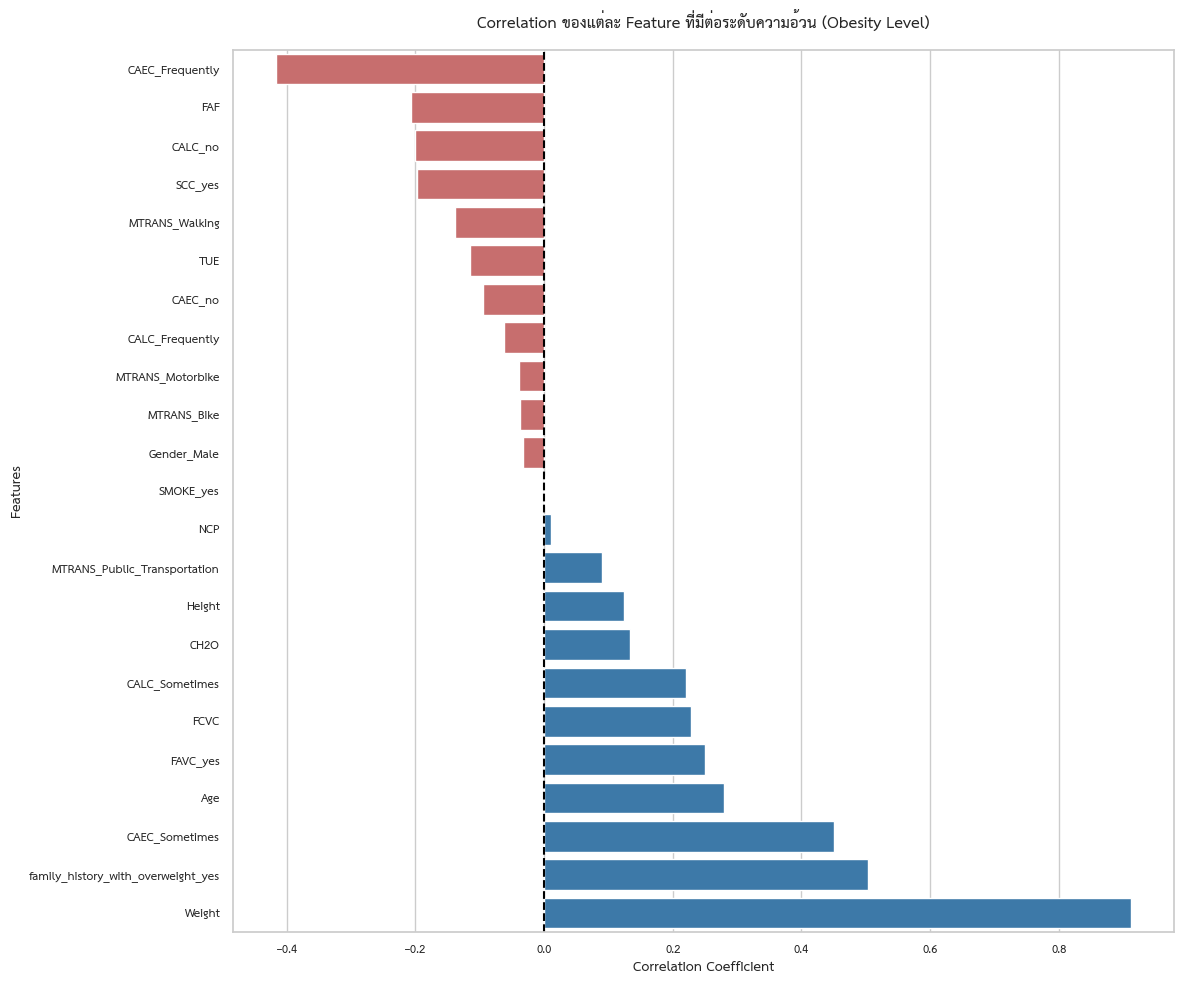

In [13]:
# ─── 3.2 Correlation Analysis กับ Target ────────────────────────────────
# วัตถุประสงค์: ตรวจสอบความสัมพันธ์ระหว่าง Features กับระดับภาวะน้ำหนัก

# 1. สร้าง Mapping แปลง Target ให้เป็นตัวเลข 0-6 (Ordinal Encoding)
target_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
y_num = y.map(target_mapping)

# 2. นำ X_encoded (ที่เป็นตัวเลขทั้งหมดแล้ว) มารวมกับ y_num ชั่วคราวเพื่อหา Correlation
df_corr = X_encoded.copy()
df_corr['Obesity_Level'] = y_num

# 3. คำนวณ Correlation (Pearson) เทียบกับ Target และเรียงลำดับจากน้อยไปมาก
correlations = df_corr.corr()['Obesity_Level'].drop('Obesity_Level').sort_values()

# 4. พล็อตกราฟแท่งแนวนอน (Horizontal Bar Plot)
plt.figure(figsize=(12, 10))

# กำหนดสีของแท่งตามทิศทางของค่า Correlation
colors = ['#d65f5f' if val < 0 else '#2b7bba' for val in correlations.values]

sns.barplot(x=correlations.values, y=correlations.index, palette=colors)

plt.title('Correlation ของแต่ละ Feature ที่มีต่อระดับความอ้วน (Obesity Level)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Correlation Coefficient', fontsize=14, fontweight='bold')
plt.ylabel('Features', fontsize=14, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

### 3.3 Bias-Variance Tradeoff (แสดง U-Curve ของ Train/Test MSE)
เพื่อแสดงให้เห็นถึงความสัมพันธ์ระหว่างความซับซ้อนของโมเดล (Model Complexity) กับค่าความคลาดเคลื่อน (Error) เราจะจำลองการสร้างโมเดล Decision Tree โดยปรับเปลี่ยนค่าความลึกของต้นไม้ (`max_depth`) จาก 1 ถึง 20 

แม้ว่าโจทย์นี้จะเป็น Classification แต่เนื่องจากระดับความอ้วนเป็นข้อมูลแบบมีลำดับ (Ordinal) เราจึงสามารถใช้ค่า MSE (Mean Squared Error) บนตัวเลข 0-6 มาพล็อตกราฟเพื่อแสดงพฤติกรรม Overfitting ได้ โดยเมื่อโมเดลซับซ้อนขึ้น (ลึกขึ้น) Train MSE จะลดลงเข้าสู่ 0 (Low Bias) แต่ Test MSE จะลดลงในตอนแรกแล้วเริ่มเด้งกลับสูงขึ้นหรือคงที่ (High Variance) ซึ่งเป็นลักษณะของ U-Curve ตามทฤษฎี Statistical Learning

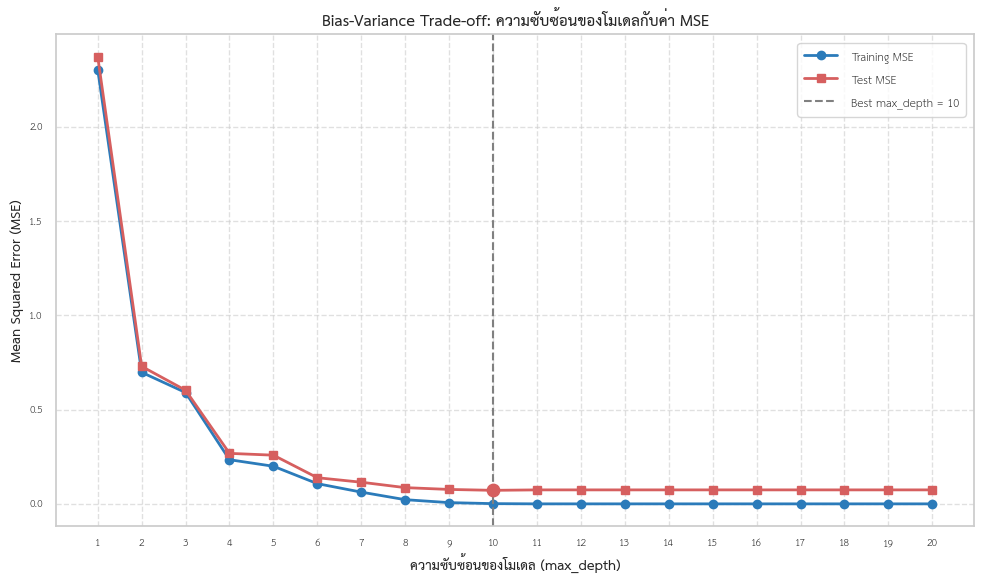

Best max_depth: 10
Lowest Test MSE: 0.0718


In [14]:
# ─── 3.3 Bias-Variance Trade-off: Train/Test MSE ─────────────────────
# วัตถุประสงค์: วิเคราะห์ผลของความซับซ้อนของโมเดลต่อค่า Train MSE และ Test MSE

# 1. แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    df_corr['Obesity_Level'],
    test_size=0.2,
    random_state=42,
    stratify=df_corr['Obesity_Level']
)

train_mse = []
test_mse = []

# 2. ทดสอบความซับซ้อนของ Decision Tree
depths = range(1, 21)

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # คำนวณ MSE ของข้อมูล Train และ Test
    train_mse.append(
        mean_squared_error(y_train, y_train_pred)
    )

    test_mse.append(
        mean_squared_error(y_test, y_test_pred)
    )

# 3. หาค่า depth ที่ให้ Test MSE ต่ำที่สุด
best_depth = depths[np.argmin(test_mse)]
best_test_mse = min(test_mse)

# 4. Plot
plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_mse,
    label='Training MSE',
    color='#2b7bba',
    marker='o',
    linewidth=2
)

plt.plot(
    depths,
    test_mse,
    label='Test MSE',
    color='#d65f5f',
    marker='s',
    linewidth=2
)

plt.axvline(
    best_depth,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label=f'Best max_depth = {best_depth}'
)

plt.scatter(best_depth,best_test_mse, color='#d65f5f', s=80, zorder=5)
plt.title('Bias-Variance Trade-off: ความซับซ้อนของโมเดลกับค่า MSE', fontsize=16, fontweight='bold')
plt.xlabel('ความซับซ้อนของโมเดล (max_depth)', fontsize=14, fontweight='bold')
plt.ylabel('Mean Squared Error (MSE)', fontsize=14, fontweight='bold')
plt.xticks(depths)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Best max_depth: {best_depth}")
print(f"Lowest Test MSE: {best_test_mse:.4f}")

**Insight จาก CLO2 Analysis:**

> 1. **การกระจายตัวของข้อมูล:** ตัวแปรน้ำหนัก (Weight) มีการกระจายตัวแบบหลายยอด (Multimodal) ซึ่งอาจสะท้อนการรวมกันของกลุ่มตัวอย่างที่มีระดับภาวะน้ำหนักแตกต่างกัน
>
> 2. **ความสัมพันธ์กับระดับภาวะน้ำหนัก:** น้ำหนัก (Weight) มีความแตกต่างระหว่างแต่ละระดับภาวะน้ำหนักอย่างชัดเจน ขณะที่ประวัติครอบครัวที่มีภาวะน้ำหนักเกิน (Family History) มีความสัมพันธ์กับระดับภาวะน้ำหนักอย่างมีนัยสำคัญทางสถิติจากการทดสอบ Chi-Square (p < 0.05)
>
> 3. **Bias-Variance Trade-off:** เมื่อเพิ่มความซับซ้อนของ Decision Tree ค่า Training Error มีแนวโน้มลดลงอย่างต่อเนื่อง ขณะที่ Test Error ลดลงในช่วงแรกและให้ค่าต่ำที่สุดที่ `max_depth = 10` โดยมี Test MSE เท่ากับ `0.0718` หลังจากนั้นการเพิ่มความซับซ้อนไม่ได้ช่วยลด Test Error อย่างต่อเนื่อง สะท้อนแนวโน้มของ Overfitting และความสำคัญของการเลือก Hyperparameter ที่เหมาะสม

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ:** ✅ Classification

> **เหตุผลในการเลือก:** ตัวแปรเป้าหมาย (`NObeyesdad`) เป็นข้อมูลเชิงกลุ่ม (Categorical) ที่แบ่งระดับภาวะน้ำหนักและโรคอ้วนออกเป็น 7 คลาส (Multi-class Classification) ได้แก่ *Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II* และ *Obesity Type III* จึงจำเป็นต้องใช้แบบจำลองการจำแนกประเภท (Classification Model) ในการทำนาย

---
### 4.1 การเตรียมข้อมูล (Train/Test Split & Feature Scaling)
ทำการแบ่งข้อมูล Train 80% และ Test 20% โดยใช้ `stratify=y` เพื่อรักษาสัดส่วนของแต่ละคลาสให้สมดุลเท่ากันทั้งสองชุด พร้อมทั้งทำ Feature Scaling ด้วย `StandardScaler` (Fit เฉพาะ Train เพื่อป้องกัน Data Leakage) เนื่องจากทั้ง Logistic Regression และ KNN ไวต่อสเกลของข้อมูล

🎯 Model 1 (Logistic Regression) Accuracy: 89.23%

Train Accuracy: 89.87%
Test Accuracy : 89.23%

                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        53
      Normal_Weight       0.84      0.82      0.83        57
 Overweight_Level_I       0.77      0.80      0.79        55
Overweight_Level_II       0.82      0.71      0.76        58
     Obesity_Type_I       0.90      0.93      0.92        70
    Obesity_Type_II       0.94      0.98      0.96        60
   Obesity_Type_III       1.00      0.98      0.99        65

           accuracy                           0.89       418
          macro avg       0.89      0.89      0.89       418
       weighted avg       0.89      0.89      0.89       418



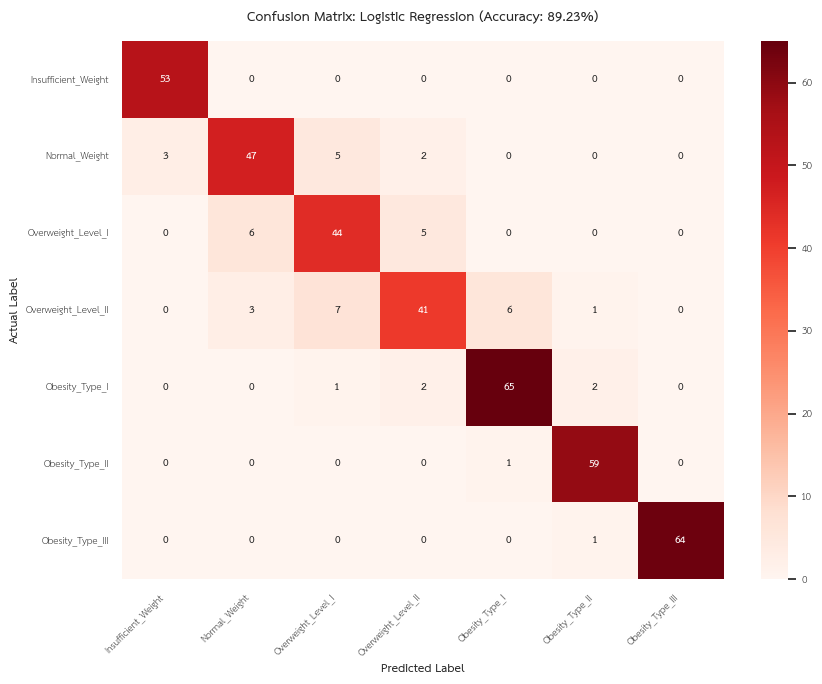

In [15]:
# ─── CLO3: Model 1 ─────────────────────────────────────────────────
# วัตถุประสงค์: สร้างแบบจำลอง Multi-class Logistic Regression เพื่อจำแนกระดับความอ้วน (7 คลาส)

# 1. แบ่งชุดข้อมูล Train 80% / Test 20% แบบ Stratified เพื่อรักษาสัดส่วนทุกคลาส
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 2. ทำ Feature Scaling (Fit เฉพาะ Train เพื่อป้องกัน Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. กำหนดโมเดลและเทรนข้อมูล
model1 = LogisticRegression(max_iter=1000, random_state=42)
model1.fit(X_train_scaled, y_train)

# 4. ประเมินผลลัพธ์
y_train_pred1 = model1.predict(X_train_scaled)
y_pred1 = model1.predict(X_test_scaled)

train_acc1 = accuracy_score(y_train, y_train_pred1)
acc1 = accuracy_score(y_test, y_pred1)

print(f"🎯 Model 1 (Logistic Regression) Accuracy: {acc1 * 100:.2f}%\n")
print(f"Train Accuracy: {train_acc1 * 100:.2f}%")
print(f"Test Accuracy : {acc1 * 100:.2f}%\n")

print(classification_report(
    y_test, 
    y_pred1, 
    labels=target_order, 
    target_names=target_order
))


# 5. แสดงผล Confusion Matrix
plt.figure(figsize=(9, 7))
cm1 = confusion_matrix(y_test, y_pred1, labels=target_order)
sns.heatmap(
    cm1, annot=True, fmt='d', cmap='Reds', 
    xticklabels=target_order, yticklabels=target_order,
    annot_kws={"fontsize": 11, "fontweight": "bold"}
)

plt.title(f'Confusion Matrix: Logistic Regression (Accuracy: {acc1*100:.2f}%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

🎯 Model 2 (KNN Classifier k=5)
Train Accuracy: 86.34%
Test Accuracy : 80.86%

                     precision    recall  f1-score   support

Insufficient_Weight       0.76      0.94      0.84        53
      Normal_Weight       0.58      0.49      0.53        57
 Overweight_Level_I       0.68      0.62      0.65        55
Overweight_Level_II       0.86      0.72      0.79        58
     Obesity_Type_I       0.84      0.90      0.87        70
    Obesity_Type_II       0.89      0.95      0.92        60
   Obesity_Type_III       0.97      0.98      0.98        65

           accuracy                           0.81       418
          macro avg       0.80      0.80      0.80       418
       weighted avg       0.80      0.81      0.80       418



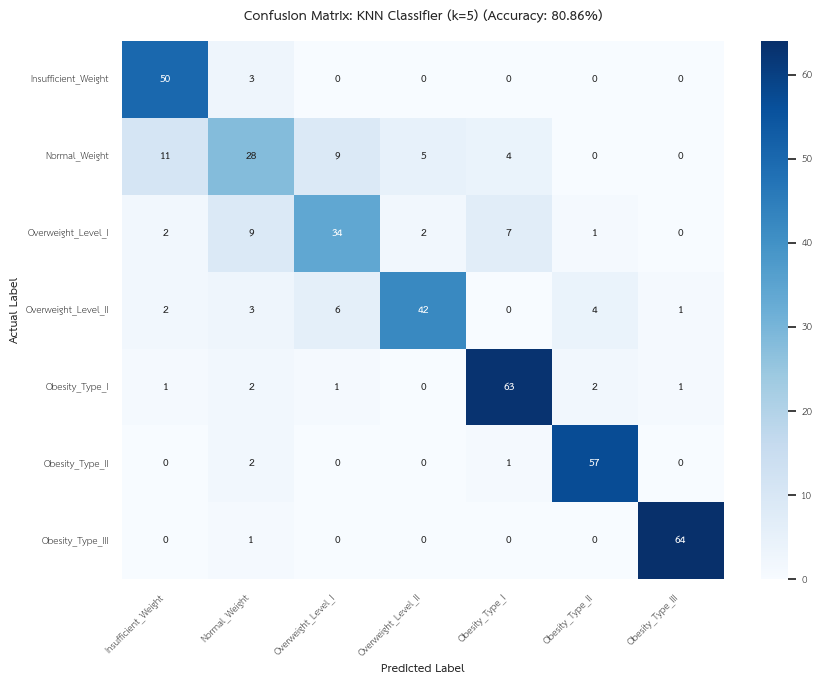

In [16]:
# ─── CLO3: Model 2 ─────────────────────────────────────────────────
# วัตถุประสงค์: สร้างแบบจำลอง K-Nearest Neighbors (KNN Classifier)
# เพื่อจำแนกระดับภาวะน้ำหนักโดยวัดระยะทาง Euclidean

# 1. กำหนดโมเดล KNN (k=5) และเทรนข้อมูล
model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train_scaled, y_train)

# 2. ประเมินผลลัพธ์
# ทำนายผลทั้งข้อมูล Train และ Test เพื่อเปรียบเทียบประสิทธิภาพ
y_train_pred2 = model2.predict(X_train_scaled)
y_pred2 = model2.predict(X_test_scaled)

train_acc2 = accuracy_score(y_train, y_train_pred2)
acc2 = accuracy_score(y_test, y_pred2)

print(f"🎯 Model 2 (KNN Classifier k=5)")
print(f"Train Accuracy: {train_acc2 * 100:.2f}%")
print(f"Test Accuracy : {acc2 * 100:.2f}%\n")

print(classification_report(
    y_test,
    y_pred2,
    labels=target_order,
    target_names=target_order
))

# 3. แสดงผล Confusion Matrix
# ใช้ดูจำนวนการทำนายถูกและผิดในแต่ละระดับภาวะน้ำหนัก
plt.figure(figsize=(9, 7))

cm2 = confusion_matrix(
    y_test, y_pred2, labels=target_order
)

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_order,
    yticklabels=target_order,
    annot_kws={"fontsize": 11, "fontweight": "bold"}
)

plt.title(f'Confusion Matrix: KNN Classifier (k=5) 'f'(Accuracy: {acc2*100:.2f}%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

### สรุป Model Comparison

| Model                             |        Train Metric        |                   Test Metric                  | รายละเอียด                                                                            |
| :-------------------------------- | :------------------------: | :--------------------------------------------: | :------------------------------------------------------------------------------------ |
| **Model 1: Logistic Regression**  | Train Accuracy: **89.87%** | Test Accuracy: **89.23%** (Macro F1: **0.89**) | แบบจำลองเชิงเส้นสำหรับ Multi-class Classification โดยใช้ Softmax Function             |
| **Model 2: KNN Classifier (k=5)** | Train Accuracy: **86.34%** | Test Accuracy: **80.86%** (Macro F1: **0.80**) | แบบจำลองที่จำแนกข้อมูลจากระยะห่างของตัวอย่างที่ใกล้เคียงกัน โดยใช้ Euclidean Distance |

### Insight

> 1. **การเปรียบเทียบประสิทธิภาพ:**
>    Logistic Regression ให้ผลการทดสอบสูงกว่า KNN ในชุดข้อมูลนี้ โดยมี Test Accuracy สูงกว่า **8.37 จุดเปอร์เซ็นต์** (89.23% เทียบกับ 80.86%) และมี Macro F1 สูงกว่า (**0.89 เทียบกับ 0.80**) แสดงว่า Logistic Regression สามารถจำแนกข้อมูลในชุดทดสอบได้ดีกว่าในการทดลองครั้งนี้
>
> 2. **ความสามารถในการ Generalize:**
>    Logistic Regression มีช่องว่างระหว่าง Train และ Test Accuracy เพียง **0.64 จุดเปอร์เซ็นต์** (89.87% − 89.23%) ขณะที่ KNN มีช่องว่าง **5.48 จุดเปอร์เซ็นต์** (86.34% − 80.86%) แสดงว่า Logistic Regression มีความแตกต่างระหว่างผลการฝึกและผลการทดสอบน้อยกว่าในชุดการทดลองนี้
>
> 3. **การวิเคราะห์จุดบกพร่องรายคลาส:**
>    KNN มีจุดอ่อนที่เห็นได้ชัดในกลุ่ม `Normal_Weight` โดยมี Recall เพียง **49%** ขณะที่ Logistic Regression สามารถจำแนกหลายคลาสได้ในระดับสูงกว่า ความแตกต่างดังกล่าวอาจเกี่ยวข้องกับโครงสร้างของข้อมูลและการคำนวณระยะห่าง Euclidean ใน feature space ซึ่งหลังการเข้ารหัสข้อมูลมีจำนวนตัวแปรเพิ่มขึ้น
>
> 4. **การพิจารณา Overfitting:**
>    จากผลการทดลองนี้ Logistic Regression มีช่องว่างระหว่าง Train และ Test Accuracy เพียง **0.64 จุดเปอร์เซ็นต์** จึงยังไม่พบสัญญาณของ Overfitting ที่ชัดเจนจากการแบ่งข้อมูลครั้งนี้ ส่วน KNN มีช่องว่างมากกว่า ดังนั้นควรตรวจสอบความสม่ำเสมอของผลลัพธ์ด้วย **Cross-Validation ใน CLO4** ก่อนสรุปประสิทธิภาพของโมเดลขั้นสุดท้าย


---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

### 5.1 การประเมินและคัดเลือกแบบจำลองด้วย 5-Fold Stratified Cross-Validation
ทำการเปรียบเทียบประสิทธิภาพแบบจำลอง 3 ตัวอย่างเป็นธรรม โดยใช้ `StratifiedKFold` (5 Folds) เพื่อรักษาสัดส่วนของทั้ง 7 คลาสในทุก Fold และใช้ `Pipeline` คู่กับ `StandardScaler` เพื่อป้องกันการรั่วไหลของข้อมูล (Data Leakage) ระหว่างการทำ CV:
1. **Model 1: Logistic Regression** (Linear Model ผ่าน Softmax)
2. **Model 2: KNN Classifier (k=5)** (Distance-based Model)
3. **Model 3: Random Forest Classifier** (Ensemble Tree-based Model)

*(หมายเหตุ: เนื่องจากชุดข้อมูลเป็น Classification จึงเปลี่ยนเมทริกซ์การวัดผลจาก MSE เป็น Accuracy)*

=== ตารางผลลัพธ์ 5-Fold Stratified Cross-Validation ===


,Logistic Regression,KNN (k=5),Random Forest
Fold 1,86.84%,81.82%,96.65%
Fold 2,85.65%,78.23%,93.06%
Fold 3,88.49%,78.18%,95.20%
Fold 4,86.81%,79.86%,93.05%
Fold 5,87.77%,80.82%,94.96%
Mean Accuracy,87.11%,79.78%,94.59%
Std Dev (±),±1.08%,±1.60%,±1.54%


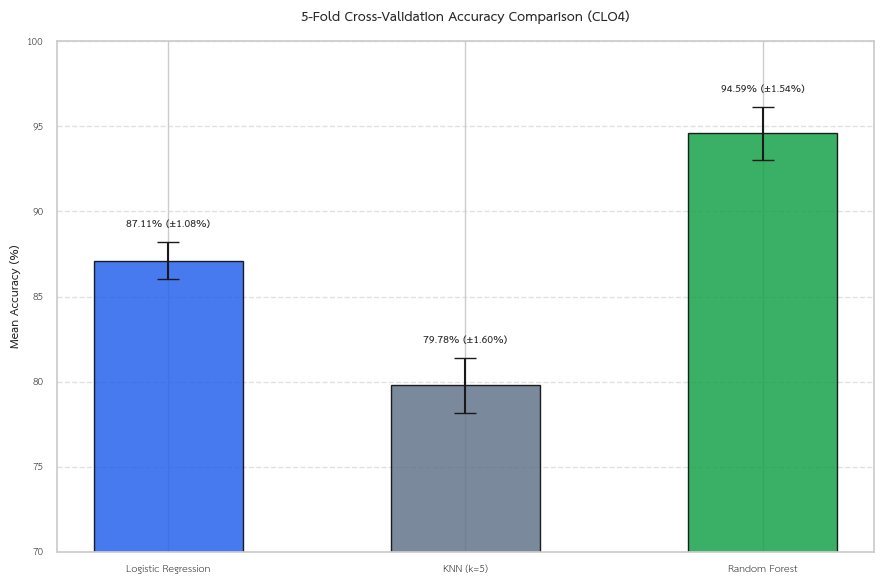

In [17]:
# ─── CLO4: 5-Fold Cross-Validation ────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบประสิทธิภาพของ Models อย่างเป็นธรรมด้วย 5-Fold Stratified Cross-Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# กำหนด Models ที่ต้องการเปรียบเทียบ โดยใช้ Pipeline เพื่อจัดการ Scaling ภายในแต่ละ Fold
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "KNN (k=5)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ])
}

# เก็บผล Accuracy ของแต่ละ Fold สำหรับแต่ละ Model
fold_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_encoded, y, cv=cv, scoring='accuracy', n_jobs=-1)
    fold_results[name] = scores * 100

df_cv = pd.DataFrame(fold_results, index=[f"Fold {i+1}" for i in range(5)])

# สรุปค่า Mean Accuracy และ Standard Deviation ของแต่ละ Model
df_summary = pd.DataFrame({
    model: [
        f"{df_cv[model].mean():.2f}%",
        f"±{df_cv[model].std():.2f}%"
    ] for model in models.keys()
}, index=["Mean Accuracy", "Std Dev (±)"])

df_display = pd.concat([df_cv.map(lambda x: f"{x:.2f}%"), df_summary])

print("=== ตารางผลลัพธ์ 5-Fold Stratified Cross-Validation ===")
display(df_display)

cv_means = df_cv.mean()
cv_stds = df_cv.std()

# แสดงค่า Mean Accuracy และ Standard Deviation ของแต่ละ Model
plt.figure(figsize=(9, 6))
bars = plt.bar(
    cv_means.index, cv_means.values, yerr=cv_stds.values, 
    capsize=8, color=['#2563eb', '#64748b', '#16a34a'], edgecolor='black', alpha=0.85, width=0.5
)

plt.title('5-Fold Cross-Validation Accuracy Comparison (CLO4)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Mean Accuracy (%)', fontsize=12, fontweight='bold')
plt.ylim(70, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar, mean_val, std_val in zip(bars, cv_means.values, cv_stds.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2, mean_val + std_val + 0.8,
        f"{mean_val:.2f}% (±{std_val:.2f}%)", 
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

### Best Model จาก Cross-Validation: Random Forest Classifier

**เหตุผล:**

> 1. **ประสิทธิภาพสูงสุดในการประเมินผล (Highest CV Metric):**
>    Random Forest Classifier ให้ผลการประเมินดีที่สุด โดยมีค่าเฉลี่ย **5-Fold CV Accuracy สูงถึง 94.59% (±1.54%)** ซึ่งสูงกว่า Logistic Regression ที่ **87.11%** และ KNN ที่ **79.78%** อย่างชัดเจน คิดเป็นอัตราความผิดพลาดเฉลี่ยประมาณ **5.41%**
>
> 2. **การประเมินความสม่ำเสมอของผลลัพธ์:**
>    Random Forest ให้ค่า Accuracy ในทั้ง 5 Folds อยู่ระหว่าง **93.05%–96.65%** และมี Standard Deviation เท่ากับ **±1.54%** แสดงให้เห็นว่าประสิทธิภาพของโมเดลมีความสม่ำเสมอในหลายชุดข้อมูลที่ใช้ตรวจสอบ จึงมีแนวโน้มที่จะ Generalize ได้ดีในการทดลองนี้ อย่างไรก็ตาม Cross-Validation เพียงอย่างเดียวยังไม่เพียงพอที่จะยืนยันการไม่มี Overfitting ได้อย่างสมบูรณ์
>
> 3. **การเชื่อมโยงกับทฤษฎี Bias-Variance Trade-off:**
>    จากการวิเคราะห์ในข้อ 3.3 พบว่า Decision Tree ที่มีความซับซ้อนสูงมีแนวโน้มเกิด **High Variance** ได้ Random Forest จึงใช้แนวคิด **Ensemble Learning แบบ Bagging** ร่วมกับการสุ่มตัวอย่างข้อมูลและ Features เพื่อสร้าง Decision Trees หลายต้นและรวมผลการทำนายเข้าด้วยกัน แนวทางนี้ช่วยลดความผันผวนของการทำนายเมื่อเทียบกับการใช้ Tree เดียว และช่วยให้โมเดลสามารถเรียนรู้ความสัมพันธ์แบบ **Non-linear** และปฏิสัมพันธ์ระหว่าง Features ได้ดี


---
## Part 6: สรุปผลและ Data Story

### ***6.1 สรุปผลการวิเคราะห์***

โครงงานนี้ศึกษาข้อมูลด้านพฤติกรรมการกิน การใช้ชีวิต และสภาพร่างกาย เพื่อนำมาใช้ในการจำแนก **ระดับภาวะน้ำหนักและโรคอ้วน 7 ระดับ** โดยประยุกต์ใช้แนวคิดทางคณิตศาสตร์ สถิติ และ Machine Learning ตั้งแต่การวิเคราะห์ข้อมูลไปจนถึงการคัดเลือกแบบจำลอง

* **CLO1 — (Linear Algebra & PCA):**

  ประยุกต์ใช้ Covariance Matrix, Eigendecomposition และ PCA เพื่อศึกษาความสัมพันธ์เชิงโครงสร้างและทิศทางของความแปรปรวนในข้อมูล ทำให้สามารถมองเห็นข้อมูลในมิติที่ลดลงได้ง่ายขึ้น

* **CLO2 — (Statistical Learning & EDA):**

  จากการวิเคราะห์ Distribution, Correlation และ Hypothesis Testing พบว่า `Weight` มีการกระจายแตกต่างกันระหว่างระดับภาวะน้ำหนักอย่างชัดเจนจากการวิเคราะห์ Boxplot ขณะที่ `Age` แตกต่างกันระหว่างกลุ่มอย่างมีนัยสำคัญทางสถิติ และ `family_history_with_overweight` มีความสัมพันธ์กับระดับภาวะน้ำหนักจากการทดสอบ Chi-Square นอกจากนี้การวิเคราะห์ Bias-Variance พบแนวโน้มของ Overfitting เมื่อ Decision Tree มีความซับซ้อนมากขึ้น

* **CLO3 — (Model Building):**

  ทดลองใช้ Multi-class Logistic Regression และ KNN Classifier โดย Logistic Regression ให้ Test Accuracy **89.23%** และ Macro F1 **0.89** ขณะที่ KNN (k=5) ให้ Test Accuracy **80.86%** และ Macro F1 **0.80**

* **CLO4 — (Model Selection):**

  ทำการเปรียบเทียบ Logistic Regression, KNN และ Random Forest ด้วย **5-Fold Stratified Cross-Validation** พบว่า Random Forest ให้ Mean CV Accuracy สูงที่สุดที่ **94.59% (±1.54%)** โดยผล Accuracy ของทั้ง 5 Folds อยู่ในช่วง **93.05%–96.65%** จึงเป็นแบบจำลองที่เหมาะสมที่สุดสำหรับงาน Classification นี้จากแบบจำลองที่นำมาเปรียบเทียบ

> **Overall Finding:**
> ผลการทดลองแสดงให้เห็นว่า ข้อมูลด้านพฤติกรรมการกิน การใช้ชีวิต และสภาพร่างกายสามารถนำมาใช้ในการจำแนกระดับภาวะน้ำหนัก 7 ระดับได้ และจากแบบจำลองที่นำมาทดสอบ **Random Forest ให้ผลดีที่สุดในการทดลองนี้** เมื่อพิจารณาจาก Mean 5-Fold Cross-Validation Accuracy

---

### ***6.2 Limitations***

แม้ผลการทดลองจะให้ประสิทธิภาพในระดับสูง แต่ยังมีข้อจำกัดที่ควรพิจารณาในการตีความผลลัพธ์

1. **ลักษณะของ Dataset:**
   Dataset ประกอบด้วยทั้งข้อมูลจริงและข้อมูลสังเคราะห์ ดังนั้นผลการทดลองไม่ควรนำไปตีความว่าเป็นตัวแทนของประชากรจริงทั้งหมด

2. **โครงสร้างของ Target:**
   `NObeyesdad` มีความเกี่ยวข้องกับข้อมูลด้านน้ำหนักและส่วนสูง ดังนั้นประสิทธิภาพที่สูงของโมเดลควรตีความในบริบทของโครงสร้าง Dataset นี้

3. **การ Generalize ไปยังข้อมูลภายนอก:**
   การประเมินโมเดลทั้งหมดดำเนินการภายใน Dataset เดิม จึงยังไม่ได้ทดสอบกับ Dataset จากแหล่งอื่น

4. **การตีความเชิงสาเหตุ:**
   โครงงานนี้เน้นการจำแนกและการศึกษาความสัมพันธ์ของตัวแปร ไม่ได้ออกแบบมาเพื่อพิสูจน์ความสัมพันธ์เชิงเหตุและผล (Causality)

---

### ***6.3 ขั้นตอนต่อไป (Future Work)***

หากมีเวลาและข้อมูลเพิ่มเติม สามารถต่อยอดโครงงานได้ดังนี้

* ทำ **Hyperparameter Tuning** สำหรับ Random Forest เพื่อค้นหาค่าพารามิเตอร์ที่เหมาะสมมากขึ้น
* ทดลองเปรียบเทียบกับ Classification Models อื่น เช่น SVM หรือ Gradient Boosting
* ทดสอบโมเดลกับ **External Dataset** เพื่อประเมินความสามารถในการ Generalize
* วิเคราะห์ **Feature Importance** เพื่อศึกษาว่าตัวแปรใดมีบทบาทต่อการจำแนกมากที่สุด
* พัฒนาโมเดลเป็น **Web Application หรือ API** สำหรับนำไปใช้งานจริง ซึ่งสามารถต่อยอดไปสู่กระบวนการด้าน ML Engineering ได้

---

### ***6.4 Connection กับ Topics และ CLO ในวิชา***

โครงงานนี้นำความรู้จากรายวิชา **Mathematics for Data Science** ที่เกี่ยวข้องกับแต่ละ CLO มาประยุกต์ใช้จริง ดังนี้

|      Week      |    CLO   | Topic                                                | การประยุกต์ใช้ในโครงงาน                                                                                                      |
| :------------: | :------: | :--------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------- |
|   **Week 4**   | **CLO1** | Eigenvalues, Eigenvectors, SVD & PCA                 | ประยุกต์ใช้ PCA เพื่อวิเคราะห์โครงสร้างของข้อมูลและความแปรปรวน พร้อมแสดง Explained Variance และการแสดงผลข้อมูลใน 2 มิติด้วย PC1 และ PC2 |
|  **Week 6–7**  | **CLO2** | Bias-Variance Trade-off, EDA & Statistical Inference | วิเคราะห์ Distribution, Hypothesis Testing และ Training/Test Error ของ Decision Tree                                         |
| **Week 11–13** | **CLO3** | Classification, Logistic Regression, KNN & Pipeline  | สร้าง Multi-class Logistic Regression และ KNN Classifier พร้อมประเมินผลด้วย Accuracy, Confusion Matrix และ Macro F1 รวมถึงประยุกต์ใช้ Pipeline และ StandardScaler ในกระบวนการสร้างและประเมินโมเดล |
|   **Week 14**  | **CLO4** | Cross-Validation & Model Selection                   | ใช้ 5-Fold Stratified Cross-Validation เพื่อเปรียบเทียบและคัดเลือกโมเดลที่เหมาะสม                                               |

<br>

> โครงงานนี้ประยุกต์ใช้ความรู้จาก **Week 4 → Week 6–7 → Week 11–13 → Week 14** ตั้งแต่ **การวิเคราะห์โครงสร้างข้อมูล → การวิเคราะห์ข้อมูล → การสร้าง Classification Model → การประเมินและคัดเลือกโมเดล**

---

### ***Acknowledgements***
ขอขอบคุณแหล่งที่มาข้อมูล

* **UCI Machine Learning Repository** — แหล่งข้อมูลหลักของ Dataset
* **Kaggle** — แหล่งข้อมูลสำหรับประกอบการศึกษา
* **Python Open-Source Libraries** — NumPy, Pandas, SciPy, Matplotlib, Seaborn และ Scikit-learn
* **Course Materials** — เอกสารและสื่อการเรียนรู้จากรายวิชา 1145 201 Mathematics for Data Science